Conjunto de Datos 4: monthly-car-sales.csv


# 1. Análisis Exploratorio:

#Pandas profiling

ANÁLISIS DE VENTAS MENSUALES DE AUTOS

Período analizado: January 1960 - December 1968
Total de meses: 108
Años completos: 9

ESTADÍSTICAS DESCRIPTIVAS:
----------------------------------------
Ventas promedio mensual: 14,595 unidades
Desviación estándar: 4,525 unidades
Ventas mínimas: 5,568 (September 1962)
Ventas máximas: 26,099 (May 1968)
Rango: 20,531 unidades
Coeficiente de variación: 31.0%

Crecimiento promedio mensual: 81.2 unidades/mes
Crecimiento promedio anual: 974 unidades/año


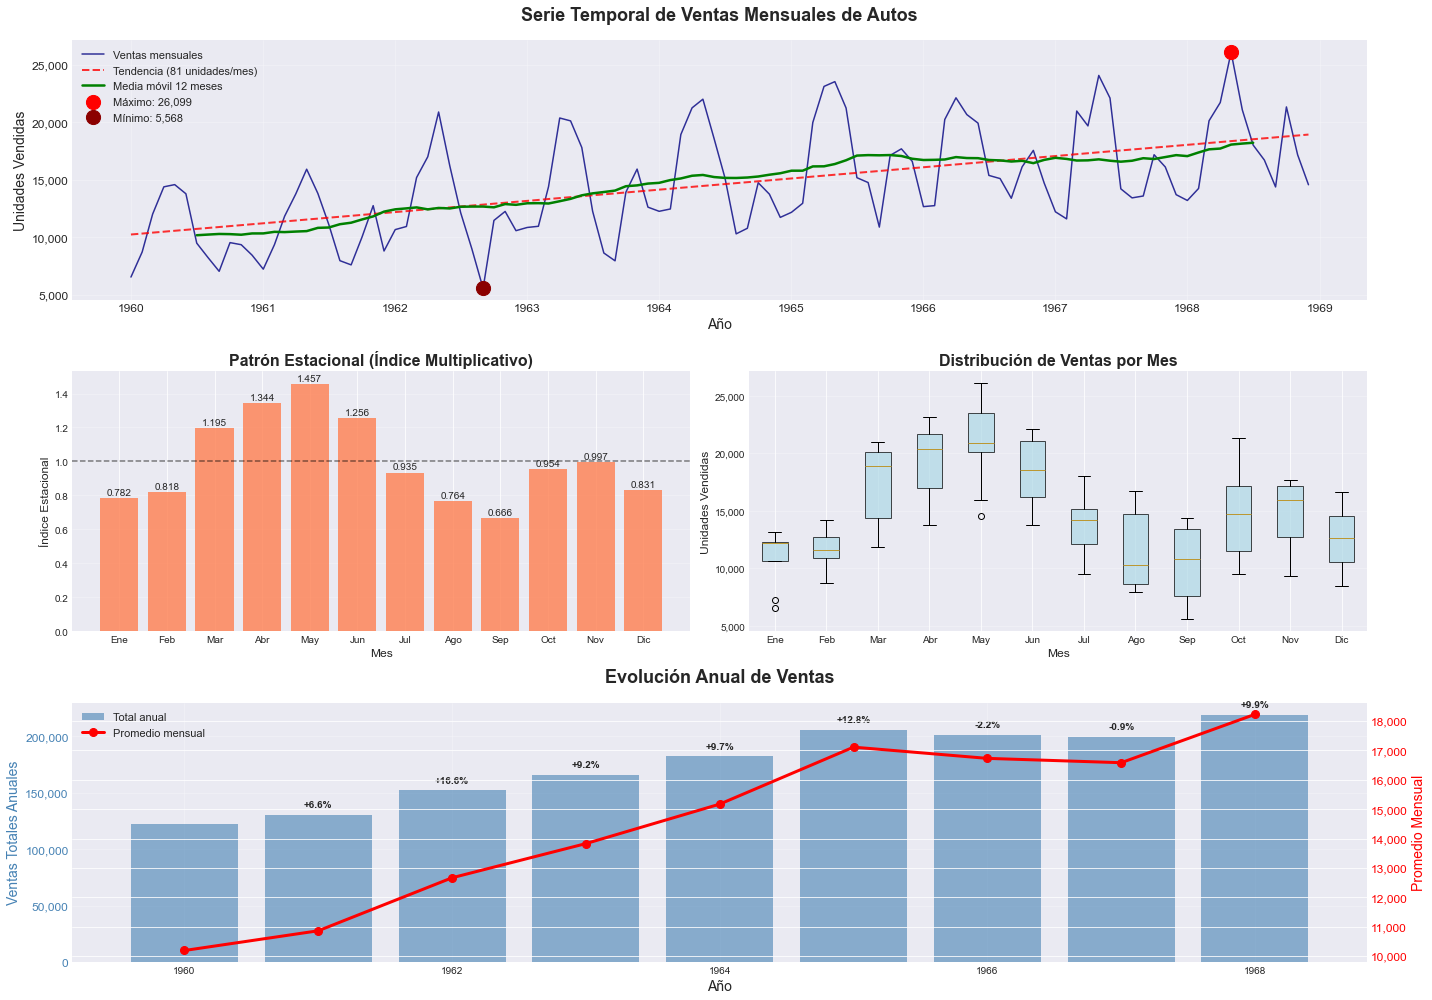

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.linear_model import LinearRegression

from scipy import stats

# Configuración de estilo
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Cargar datos
df = pd.read_csv('./monthly-car-sales.csv')

# Convertir la columna Month a datetime
# Asumiendo que el formato es como "1960-01" o similar
df['Month'] = pd.to_datetime(df['Month'])
df = df.sort_values('Month')
df.set_index('Month', inplace=True)

# Crear variables adicionales
df['Year'] = df.index.year
df['MonthNum'] = df.index.month
df['Quarter'] = df.index.quarter

# Estadísticas descriptivas
print("=" * 70)
print("ANÁLISIS DE VENTAS MENSUALES DE AUTOS")
print("=" * 70)
print(f"\nPeríodo analizado: {df.index.min().strftime('%B %Y')} - {df.index.max().strftime('%B %Y')}")
print(f"Total de meses: {len(df)}")
print(f"Años completos: {len(df) // 12}")

print("\nESTADÍSTICAS DESCRIPTIVAS:")
print("-" * 40)
print(f"Ventas promedio mensual: {df['Sales'].mean():,.0f} unidades")
print(f"Desviación estándar: {df['Sales'].std():,.0f} unidades")
print(f"Ventas mínimas: {df['Sales'].min():,} ({df['Sales'].idxmin().strftime('%B %Y')})")
print(f"Ventas máximas: {df['Sales'].max():,} ({df['Sales'].idxmax().strftime('%B %Y')})")
print(f"Rango: {df['Sales'].max() - df['Sales'].min():,} unidades")
print(f"Coeficiente de variación: {(df['Sales'].std() / df['Sales'].mean() * 100):.1f}%")

# Calcular tendencia
X = np.arange(len(df)).reshape(-1, 1)
y = df['Sales'].values
lr = LinearRegression()
lr.fit(X, y)
trend_line = lr.predict(X)
monthly_growth = lr.coef_[0]
print(f"\nCrecimiento promedio mensual: {monthly_growth:.1f} unidades/mes")
print(f"Crecimiento promedio anual: {monthly_growth * 12:.0f} unidades/año")

# Crear figura con las 3 visualizaciones más relevantes
fig = plt.figure(figsize=(20, 14))

# ========================================
# 1. SERIE TEMPORAL CON ANÁLISIS COMPLETO
# ========================================
ax1 = plt.subplot(3, 1, 1)

# Plot principal con datos originales
ax1.plot(df.index, df['Sales'], color='navy', linewidth=1.5, alpha=0.8, label='Ventas mensuales')

# Agregar línea de tendencia
ax1.plot(df.index, trend_line, 'r--', linewidth=2, alpha=0.8, label=f'Tendencia ({monthly_growth:.0f} unidades/mes)')

# Media móvil de 12 meses (elimina estacionalidad)
df['MA12'] = df['Sales'].rolling(window=12, center=True).mean()
ax1.plot(df.index, df['MA12'], color='green', linewidth=2.5, label='Media móvil 12 meses')

# Resaltar máximos y mínimos históricos
max_idx = df['Sales'].idxmax()
min_idx = df['Sales'].idxmin()
ax1.scatter(max_idx, df.loc[max_idx, 'Sales'], color='red', s=200, zorder=5, 
           label=f'Máximo: {df.loc[max_idx, "Sales"]:,}')
ax1.scatter(min_idx, df.loc[min_idx, 'Sales'], color='darkred', s=200, zorder=5,
           label=f'Mínimo: {df.loc[min_idx, "Sales"]:,}')

# Sombrear períodos de recesión si hay caídas significativas
# Identificar períodos donde las ventas caen más del 20% respecto al año anterior
df['YoY_Change'] = df['Sales'].pct_change(12) * 100
recession_periods = df[df['YoY_Change'] < -20].index

# Formato y etiquetas
ax1.set_title('Serie Temporal de Ventas Mensuales de Autos', fontsize=18, fontweight='bold', pad=20)
ax1.set_xlabel('Año', fontsize=14)
ax1.set_ylabel('Unidades Vendidas', fontsize=14)
ax1.legend(loc='upper left', fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='both', labelsize=12)

# Formatear eje Y con separadores de miles
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

# ========================================
# 2. DESCOMPOSICIÓN ESTACIONAL
# ========================================
# Realizar descomposición
decomposition = seasonal_decompose(df['Sales'], model='multiplicative', period=12)

# Subplot para componentes
ax2 = plt.subplot(3, 2, 3)
ax3 = plt.subplot(3, 2, 4)

# Componente estacional por mes
seasonal_avg = pd.DataFrame({
    'Month': range(1, 13),
    'Seasonal': decomposition.seasonal.groupby(decomposition.seasonal.index.month).mean()
})

# Graficar patrón estacional
bars = ax2.bar(seasonal_avg['Month'], seasonal_avg['Seasonal'], color='coral', alpha=0.8)
ax2.axhline(y=1, color='black', linestyle='--', alpha=0.5)
ax2.set_title('Patrón Estacional (Índice Multiplicativo)', fontsize=16, fontweight='bold')
ax2.set_xlabel('Mes', fontsize=12)
ax2.set_ylabel('Índice Estacional', fontsize=12)
ax2.set_xticks(range(1, 13))
ax2.set_xticklabels(['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 
                     'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'])
ax2.grid(True, alpha=0.3, axis='y')

# Añadir valores encima de las barras
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.005,
             f'{height:.3f}', ha='center', va='bottom', fontsize=10)

# Box plot por mes para mostrar variabilidad
monthly_data = []
month_labels = []
for month in range(1, 13):
    month_sales = df[df.index.month == month]['Sales'].values
    monthly_data.append(month_sales)
    month_labels.append(['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 
                        'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'][month-1])

bp = ax3.boxplot(monthly_data, labels=month_labels, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
    patch.set_alpha(0.7)

ax3.set_title('Distribución de Ventas por Mes', fontsize=16, fontweight='bold')
ax3.set_xlabel('Mes', fontsize=12)
ax3.set_ylabel('Unidades Vendidas', fontsize=12)
ax3.grid(True, alpha=0.3, axis='y')
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

# ========================================
# 3. ANÁLISIS DE TENDENCIA Y PRONÓSTICO
# ========================================
ax4 = plt.subplot(3, 1, 3)

# Ventas anuales
annual_sales = df.groupby('Year')['Sales'].agg(['sum', 'mean'])
years = annual_sales.index

# Crear gráfico de barras para totales anuales
bars = ax4.bar(years, annual_sales['sum'], alpha=0.6, color='steelblue', label='Total anual')

# Línea para promedio mensual por año
ax4_twin = ax4.twinx()
line = ax4_twin.plot(years, annual_sales['mean'], color='red', marker='o', 
                     linewidth=3, markersize=8, label='Promedio mensual')

# Calcular y mostrar tasa de crecimiento anual
for i in range(1, len(years)):
    growth = ((annual_sales['sum'].iloc[i] - annual_sales['sum'].iloc[i-1]) / 
              annual_sales['sum'].iloc[i-1] * 100)
    ax4.text(years[i], annual_sales['sum'].iloc[i] + 5000, f'{growth:+.1f}%', 
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# Formato y etiquetas
ax4.set_title('Evolución Anual de Ventas', fontsize=18, fontweight='bold', pad=20)
ax4.set_xlabel('Año', fontsize=14)
ax4.set_ylabel('Ventas Totales Anuales', fontsize=14, color='steelblue')
ax4_twin.set_ylabel('Promedio Mensual', fontsize=14, color='red')
ax4.tick_params(axis='y', labelcolor='steelblue', labelsize=12)
ax4_twin.tick_params(axis='y', labelcolor='red', labelsize=12)
ax4.grid(True, alpha=0.3)

# Formatear ejes Y
ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))
ax4_twin.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

# Leyendas combinadas
lines1, labels1 = ax4.get_legend_handles_labels()
lines2, labels2 = ax4_twin.get_legend_handles_labels()
ax4.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=11)

# Ajustar espaciado
plt.tight_layout()

# Guardar figura
plt.show()


# 2. Promedios Móviles:

# 3. Alisamiento Exponencial:

# 4. HOLT-WINTERS

# 5. SARIMA:

# 6. Prophet:

# 7. Comparación y Evaluación:
